In [1]:
%pip install dwave-ocean-sdk dwave-neal

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/5.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/5.2 MB 4.1 MB/s eta 0:00:02
   ---------- ----------------------------- 1.3/5.2 MB 3.6 MB/s eta 0:00:02
   ---------------- ----------------------- 2.1/5.2 MB 3.4 MB/s eta 0:00:01
   ---------------------- ----------------- 2.9/5.2 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 3.4/5.2 MB 3.4 MB/s eta 0:00:01
   -------------------------------- ------- 4.2/5.2 MB 3.4 MB/s eta 0:00:01
   -------------------------------------- - 5.0/5.2 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 5.2/5.2 MB 3.2 MB/s  0:00:01
   ---------------------------------------- 0.0/555.3 kB ? eta -:--:--
   ---------------------------------------- 555.3/555.3 kB 4.7 MB/s  0:00:00
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ---- -----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Alen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
from dwave.system.samplers import DWaveSampler
from dwave.system.composites import EmbeddingComposite
from neal import SimulatedAnnealingSampler
import networkx as nx
from dimod import Binary, ExactSolver
import numpy as np
from dwave.samplers import PathIntegralAnnealingSampler
from tqdm import tqdm
from matplotlib import pyplot as plt
import json

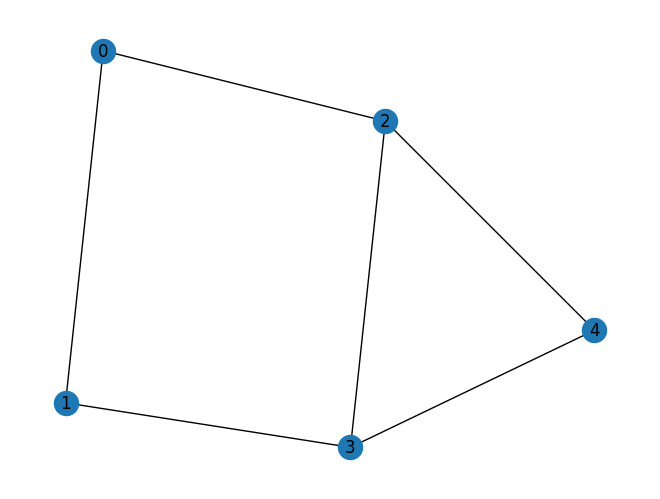

In [2]:
graph = nx.Graph()
graph.add_nodes_from([0, 1, 2, 3, 4])
graph.add_edges_from([
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 3),
    (2, 4),
    (3, 4)
])

# graph = nx.erdos_renyi_graph(20, 0.5)

nx.draw(graph, with_labels=True)


In [4]:
x = {n : Binary(n) for n in graph.nodes}

# max cut
# bqm = sum(-x[i] - x[j] + 2*x[i]*x[j] for i,j in graph.edges)

# max clique
complement_graph = nx.complement(graph)
terms = [-x[i] for i in complement_graph.nodes]
terms += [2*x[i]*x[j] for i,j in complement_graph.edges]

bqm = sum(terms)

# print(x)
# print(bqm)
# sampler = EmbeddingComposite(DWaveSampler())
# sampler = ExactSolver()
sampler = PathIntegralAnnealingSampler()
# sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, beta_schedule_type='linear', num_reads=2, num_sweeps=10000)

In [ ]:
def is_clique(graph, solution):
    solution_npy = np.array(solution)
    mask = solution_npy == 1
    node_indices = np.array(list(graph.nodes()))[mask]
    for n1 in node_indices:
        for n2 in node_indices:
            if n1 == n2:
                continue
            if not graph.has_edge(n1, n2):
                return False
    return True


def test_graph_sizes(ns, iters=10):
    clique_percent = []
    max_clique_percent = []
    
    for n in tqdm(ns):
        clique_percent_local = []
        max_clique_percent_local = []
        for i in range(iters):
            graph = nx.erdos_renyi_graph(n, 0.5)
            x = {i : Binary(i) for i in graph.nodes}
            complement_graph = nx.complement(graph)
            terms = [-x[i] for i in complement_graph.nodes]
            terms += [2*x[i]*x[j] for i,j in complement_graph.edges]
            bqm = sum(terms)
            # sampler = SimulatedAnnealingSampler()
            sampler = PathIntegralAnnealingSampler()
            num_reads = 2
            sampleset = sampler.sample(bqm, num_reads=num_reads)
            energies = np.array([s[1] for s in sampleset.record]) #  if is_clique(graph, s[0]) je do zdej blo vedno true
            clique_sizes = [sum(r[0]) for r in sampleset.record] #  if is_clique(graph, s[0]) je do zdej blo vedno true
            successful_runs = energies.shape[0]
            clique_percent_local.append(successful_runs / num_reads)
            # unique, counts = np.unique(clique_sizes, return_counts=True)
            exact_sampler = SimulatedAnnealingSampler()
            exact_sampleset = exact_sampler.sample(bqm, num_reads=50)
            # print(exact_sampleset)
            exact_max_clique = sum(exact_sampleset.lowest().record[0][0])
            max_clique_percent_local.append(np.sum(np.array(clique_sizes) == np.full_like(clique_sizes, exact_max_clique)) / num_reads)
            # print(f"Exact solution: {exact_max_clique}")
            # max_cliques_found.append()
        clique_percent.append(np.mean(clique_percent_local))
        max_clique_percent.append(np.mean(max_clique_percent_local))

    return clique_percent, max_clique_percent

ns = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
iters=10
cliques, maxcliques = test_graph_sizes(ns, iters=iters)
with open("annealing_results.json", "w") as fp:
    json.dump({
        "iters": iters,
        "ns": ns,
        "valid_clique_percent": cliques,
        "max_clique_percent": maxcliques
    }, fp)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:53<00:00,  5.33s/it]


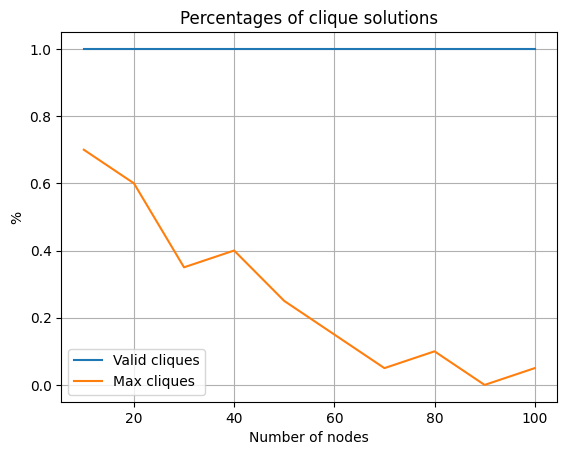

In [5]:
with open("annealing_results.json", "r") as f:
    results = json.load(f)

plt.figure()
plt.title("Percentages of clique solutions")
# plt.xticks(np.arange(len(ns)), ns)
w = 0.3
plt.plot(np.array(results["ns"]), results["valid_clique_percent"], label="Valid cliques")
plt.plot(np.array(results["ns"]), results["max_clique_percent"], label="Max cliques")
plt.legend().set_draggable(True)
plt.xlabel("Number of nodes")
plt.ylabel("%")
plt.ylim(-0.05, 1.05)
plt.grid()
plt.show()

Cut size: 252
Clique size: 7


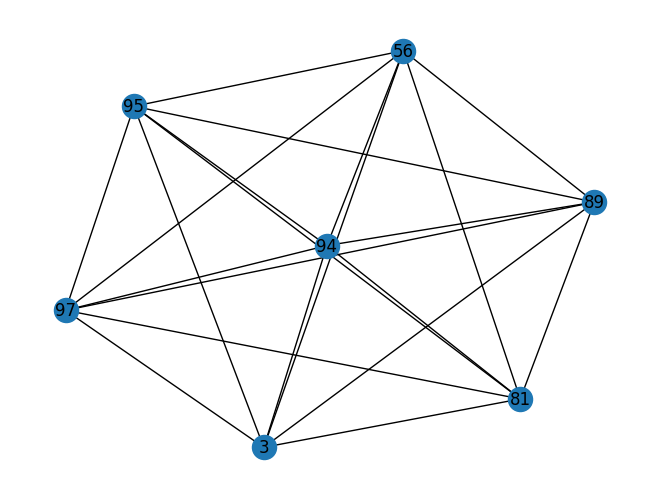

In [5]:
lowest_solution_npy = np.array(np.random.choice(sampleset.lowest().record)[0])
lowest_solution = lowest_solution_npy.tolist()


cut_size = 0
for e in graph.edges():
    cut_size += 1 if lowest_solution[e[0]] != lowest_solution[e[1]] else 0

print(f"Cut size: {cut_size}") 
print(f"Clique size: {sum(lowest_solution)}")

colors = ["tab:red" if x==1 else "tab:blue" for x in lowest_solution]
sbg = graph.subgraph([n for n in graph.nodes() if lowest_solution[n] == 1])
# nx.draw(graph, node_color=colors, with_labels=True)
nx.draw(sbg, with_labels=True)